# Partie A: Clustering

- **Dataset**: Mall Customer Segmentation Data
- **Objectifs**: Segmenter les clients du centre commercial en groupes homogènes.

In [166]:
# Importation des librairies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

# 1. Chargement:
Chargement du fichier `Mall_Customer.csv`

In [167]:
# Chargement du DataSet
dataset=pd.read_csv('../dataset/Mall_Customers.csv')
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 2. Nettoyage et prétraitement:

In [168]:
# Nettoyage et prétraitement
##  Gender : Supprimer les NaN
dataset['Gender'].dropna(inplace=True)
##  TODO Age: Superieure à 18
dataset['Age']=dataset['Age'].fillna(18)
## Normalisation de Annual Income: Positifs et Spending Score: Entre 1-100
#scaler = MinMaxScaler()
#dataset[['Annual Income (k$)', 'Spending Score (1-100)']] = scaler.fit_transform(dataset[['Annual Income (k$)', 'Spending Score (1-100)']])

## Remplacer:
##   Male   par 0
##   Female par 1
dataset['Gender']=dataset['Gender'].replace({"Male":0,"Female":1})
dataset.head()


C:\Users\Fox\AppData\Local\Temp\ipykernel_15596\4057826551.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['Gender']=dataset['Gender'].replace({"Male":0,"Female":1})


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


# 3. EDA univariée et multivariée :

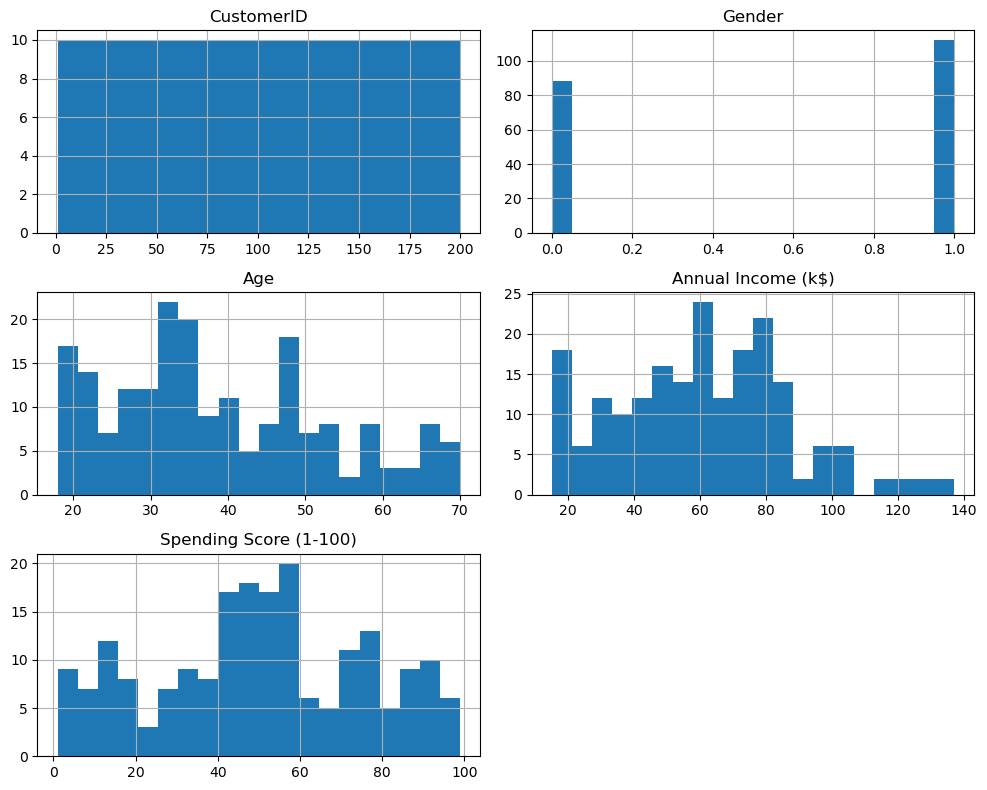

In [169]:
# Histogramme de Chaque Variables
dataset.hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

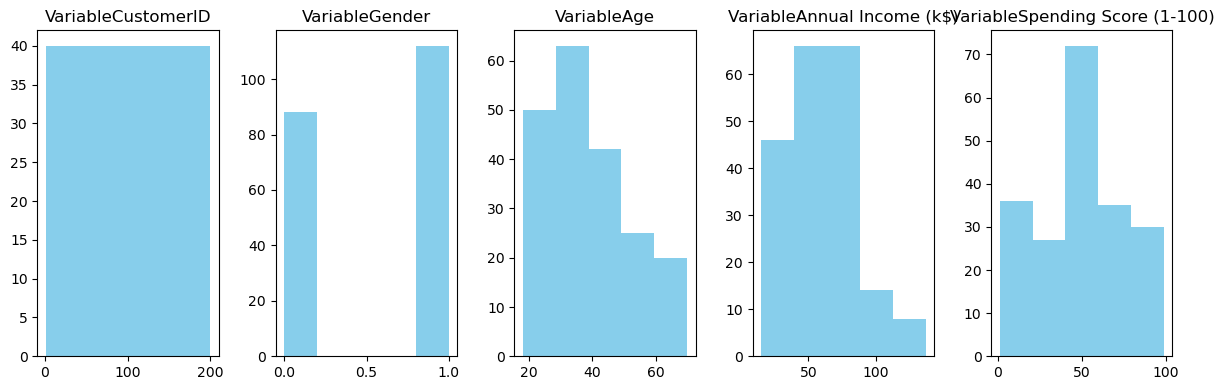

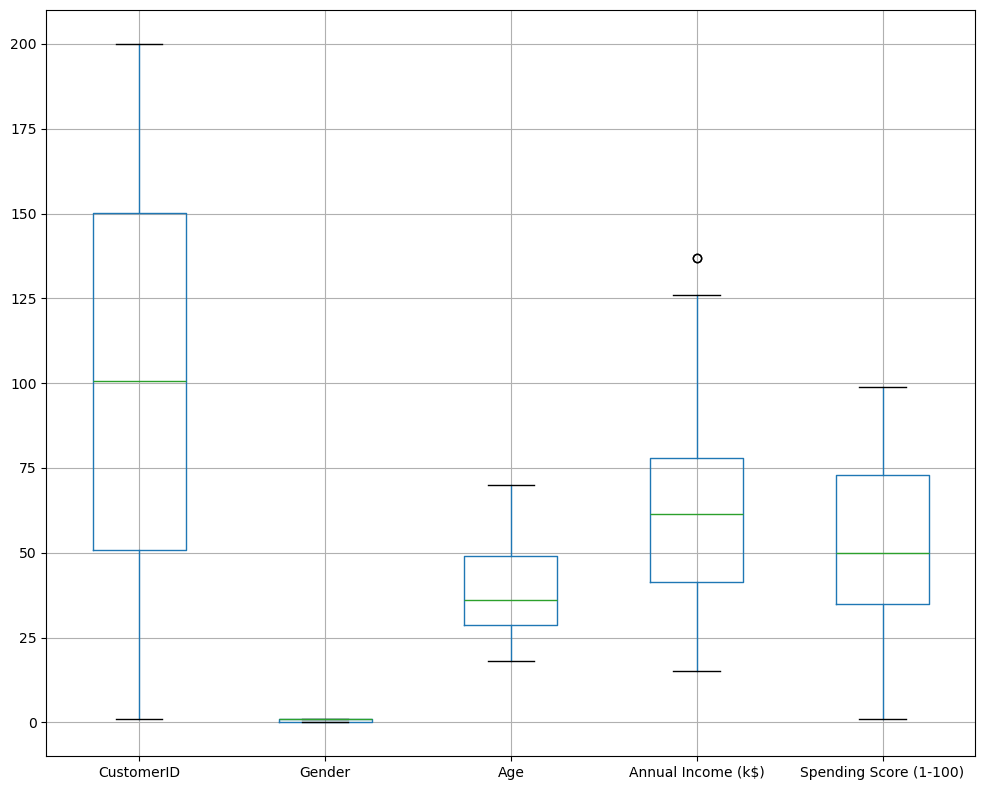

In [170]:
# BoxLayout de Chaque Variables
# Modifier en Subplot pour chaque Variable
fig, axes = plt.subplots(1, 5, figsize=(12,4))

for i, col in enumerate(dataset.columns):
    axes[i].hist(dataset[col], bins=5, color='skyblue')
    axes[i].set_title(f'Variable{col}')

plt.tight_layout()
plt.show()

dataset.boxplot(figsize=(10, 8))
plt.tight_layout()
plt.show()

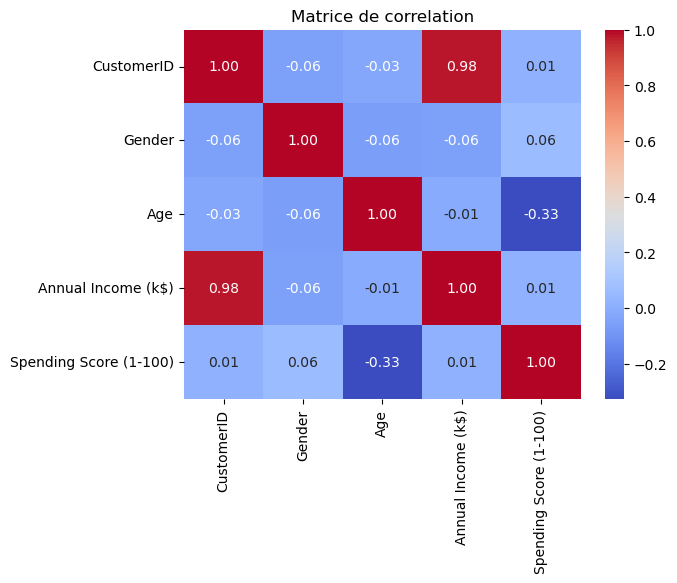

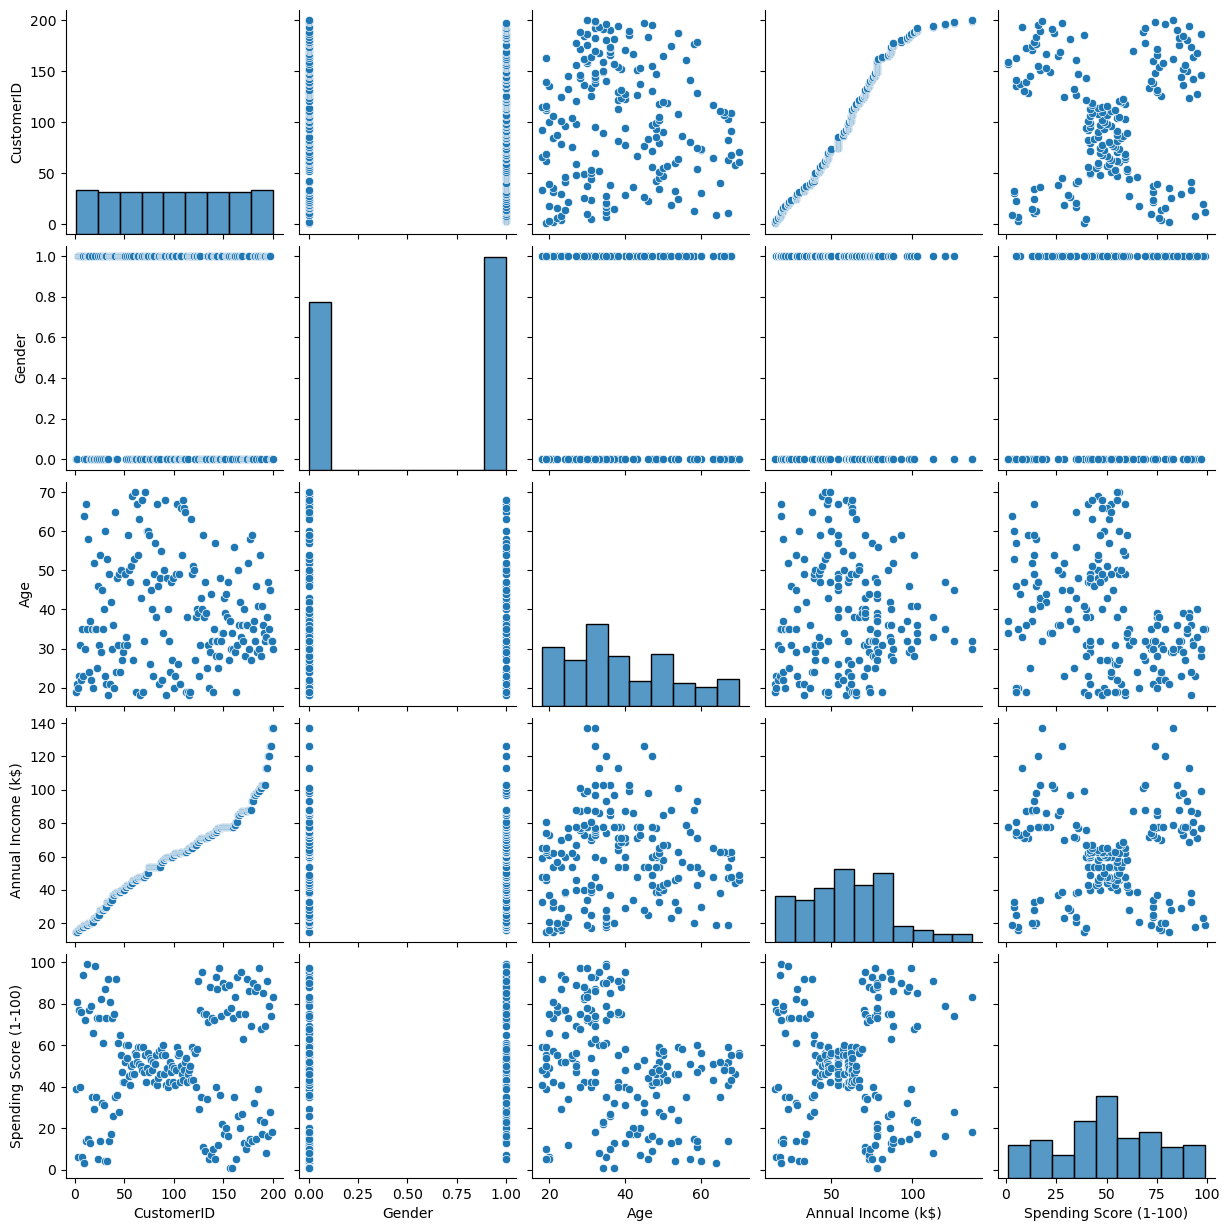

In [171]:
# Matrice de Correlation
corr_matrix=dataset.corr()
#print("La matrice de Correlation :",corr_matrix)

# Affichage en Heatmap 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de correlation')
plt.show()

# Scatter Plot
sns.pairplot(dataset, kind='scatter')
plt.show()

# 4. Feature engineering / sélection: 

In [172]:
# Supprimer les features non informatives et Redondantes
## Supprimer CustomerID car non-informatives
dataset_select=dataset.drop('CustomerID', axis=1)
dataset_select.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [ ]:
# Categoriser des Variables
#creation de nouvelle variable spending_per_Income
dataset['Spending_per_Income'] = dataset['Spending Score (1-100)'] / dataset['Annual Income (k$)']
dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
dataset.dropna(inplace=True)

# création de nouvelle variable catégorie d'age
dataset['Age_Groupe'] = pd.cut(dataset['Age'], bins=[0, 25, 40, 60, 100], labels=['Jeune', 'Adulte', 'Mature', 'Senior'])

dataset.head()



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Spending_per_Income,Age_Groupe
0,1,0,19,15,39,2.600000,Jeune
1,2,0,21,15,81,5.400000,Jeune
2,3,1,20,16,6,0.375000,Jeune
3,4,1,23,16,77,4.812500,Jeune
4,5,1,31,17,40,2.352941,Adulte


# 5. Reduction de Dimension:


In [174]:
# Application de PCA pour la Visualisation en 2D
pca = PCA(n_components=2) # 2 Composants

# Separer les features des Targets (X et Y)
## Features: Gender, Age , Annual Income
## Target : Spending Score

X=dataset_select.drop("Spending Score (1-100)",axis=1) # Exclure Spending Score
Y=dataset_select["Spending Score (1-100)"]

# Application du PCA pour Reduire en 2 dimension
X_pca=pca.fit_transform(X)

#Conversion en Dataframe
df_pca=pd.DataFrame(data=X_pca,columns=['component1','component2'])

df_pca.head()

,component1,component2
0,-45.374976,-20.266595
1,-45.393362,-18.266684
2,-44.385275,-19.259655
3,-44.412854,-16.259789
4,-43.486439,-8.250956


# 6. Clustering

In [175]:
# Clustering K means

## Variables pour Stocker les Resultats
inertias = []
silhouettes = []
K_range = range(2, 7)

## 
for i, k in enumerate(K_range, 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# 
print("Elbow:",inertias)
print("Silhouette",silhouettes)

Elbow: [87228.95732689212, 59574.616985786364, 39551.60942422728, 32820.22539682539, 25796.078872994825]
Silhouette [0.42272827955403725, 0.42270759995315615, 0.4331549993604238, 0.40145047457459926, 0.40173227570540376]


c:\Users\Fox\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Fox\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Fox\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Fox\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with M

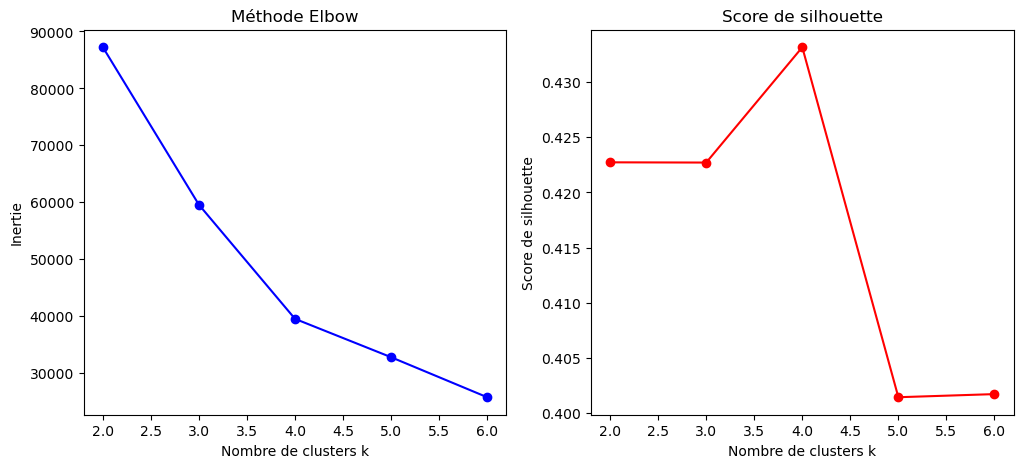

In [176]:
# Affichage de Elbow et Sihouettes

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie')
plt.title('Méthode Elbow')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, 'ro-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Score de silhouette')
plt.title('Score de silhouette')

plt.show()

# 7. Interpretation des Clusters

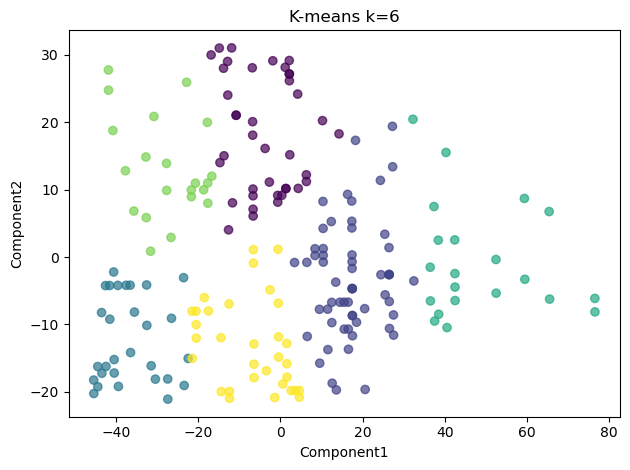

In [177]:
# Analyses Des Centroides

# TODO : analyse des centroides

# Visualisation 2D Coloré par Cluster
#plt.figure(figsize=(15, 5))

#for i, k in enumerate(K_range, 1):
    # Visualisation clusters en 2D
#plt.subplot(1, len(K_range), i)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.title(f'K-means k={k}')
plt.xlabel('Component1')
plt.ylabel('Component2')

plt.tight_layout()
plt.show()

# Conclusion

Ce projet avait pour objectif de segmenter une base de données de clients en groupes homogènes à l’aide de méthodes de clustering. Après un nettoyage rigoureux des données, nous avons sélectionné trois variables clés : l’âge, le revenu annuel et le score de dépenses, sur lesquelles nous avons appliqué des techniques de normalisation et de catégorisation. L’algorithme de clustering a permis d’identifier plusieurs profils de clients distincts, offrant ainsi une meilleure compréhension de leur comportement. Cette segmentation peut être exploitée pour affiner les stratégies marketing, personnaliser les offres ou optimiser la fidélisation. Pour aller plus loin, l’introduction de nouvelles variables, l’usage d’indicateurs d’évaluation des clusters (comme le Silhouette Score), ou l’intégration de techniques de visualisation avancées comme la PCA pourraient enrichir l’analyse et en améliorer la pertinence.